# Face GAN Training on Colab (GPU)

This notebook trains the DCGAN face generator on a free Colab GPU instead of your local CPU.

**Before running:**
1. Upload `img_align_celeba.zip` to your Google Drive (anywhere, e.g. `My Drive/img_align_celeba.zip`).
2. Go to `Runtime` -> `Change runtime type` -> select **T4 GPU** -> Save.
3. Run the cells in order (Shift+Enter on each).

## 1. Mount Google Drive

In [12]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 2. Unzip CelebA from Drive into the Colab instance

Edit `ZIP_PATH` below if your zip is somewhere else in Drive (e.g. inside a subfolder).

In [13]:
ZIP_PATH = "/content/drive/MyDrive/img_align_celeba.zip"  # <-- change if needed

import os
os.makedirs("/content/data", exist_ok=True)

!unzip -q "$ZIP_PATH" -d /content/data

# Show what we got so you can confirm the folder structure
!find /content/data -maxdepth 3 -type d
print()
!find /content/data -iname '*.jpg' | head -5
!find /content/data -iname '*.jpg' | wc -l

unzip:  cannot find or open /content/drive/MyDrive/img_align_celeba.zip, /content/drive/MyDrive/img_align_celeba.zip.zip or /content/drive/MyDrive/img_align_celeba.zip.ZIP.
/content/data

0


## 3. Set the correct image folder path

Look at the output above. If your `.jpg` files printed directly, use that folder path.
Kaggle zips are often double-nested (e.g. `img_align_celeba/img_align_celeba/*.jpg`) — if so, point at the inner folder.

In [14]:
DATA_DIR = "/content/drive/MyDrive/img_align_celeba"  # <-- adjust based on the find output above

# Quick sanity check
import glob
files = glob.glob(os.path.join(DATA_DIR, "*.jpg"))
print(f"Found {len(files)} jpg files directly in {DATA_DIR}")
if len(files) == 0:
    print("No files found directly here — check the folder structure above and update DATA_DIR (e.g. add another subfolder level).")

Found 6689 jpg files directly in /content/drive/MyDrive/img_align_celeba


## 4. Confirm GPU is active

In [15]:
import tensorflow as tf
print("GPUs available:", tf.config.list_physical_devices('GPU'))
print("TensorFlow version:", tf.__version__)
print("If the GPU list is empty, go to Runtime -> Change runtime type -> T4 GPU, then rerun from the top.")

GPUs available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
TensorFlow version: 2.20.0
If the GPU list is empty, go to Runtime -> Change runtime type -> T4 GPU, then rerun from the top.


## 5. Config

In [16]:
IMG_SIZE = 64
CROP_SIZE = 178
CHANNELS = 3

BATCH_SIZE = 128
BUFFER_SIZE = 10000
EPOCHS = 50            # start smaller than 100 on Colab; you can rerun to continue
LATENT_DIM = 100

GEN_LEARNING_RATE = 1e-4
DISC_LEARNING_RATE = 1e-4
ADAM_BETA_1 = 0.5

NUM_SAMPLE_IMAGES = 16

# Save outputs to Drive so they survive after the Colab session ends
SAMPLE_DIR = "/content/drive/MyDrive/face_gan_results/samples"
MODEL_SAVE_DIR = "/content/drive/MyDrive/face_gan_results/saved_models"
SAVE_MODEL_EVERY_N_EPOCHS = 10

os.makedirs(SAMPLE_DIR, exist_ok=True)
os.makedirs(MODEL_SAVE_DIR, exist_ok=True)

## 6. Data pipeline

In [17]:
def _normalize(img):
    img = tf.cast(img, tf.float32)
    return (img - 127.5) / 127.5

def _preprocess_image_file(file_path):
    img = tf.io.read_file(file_path)
    img = tf.image.decode_jpeg(img, channels=CHANNELS)
    img = tf.image.resize_with_crop_or_pad(img, CROP_SIZE, CROP_SIZE)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    return _normalize(img)

def build_dataset(image_dir):
    file_paths = glob.glob(os.path.join(image_dir, "*.jpg"))
    print(f"Building dataset from {len(file_paths)} images")
    ds = tf.data.Dataset.from_tensor_slices(file_paths)
    ds = ds.map(_preprocess_image_file, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.shuffle(BUFFER_SIZE).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds

dataset = build_dataset(DATA_DIR)

Building dataset from 6689 images


## 7. Generator and Discriminator

In [18]:
from tensorflow.keras import layers

def build_generator():
    model = tf.keras.Sequential(name="generator")
    model.add(layers.Input(shape=(LATENT_DIM,)))
    model.add(layers.Dense(8 * 8 * 256, use_bias=False))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU(0.2))
    model.add(layers.Reshape((8, 8, 256)))
    model.add(layers.Conv2DTranspose(128, kernel_size=4, strides=2, padding="same", use_bias=False))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU(0.2))
    model.add(layers.Conv2DTranspose(64, kernel_size=4, strides=2, padding="same", use_bias=False))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU(0.2))
    model.add(layers.Conv2DTranspose(CHANNELS, kernel_size=4, strides=2, padding="same", use_bias=False, activation="tanh"))
    return model

def build_discriminator():
    model = tf.keras.Sequential(name="discriminator")
    model.add(layers.Input(shape=(IMG_SIZE, IMG_SIZE, CHANNELS)))
    model.add(layers.Conv2D(64, kernel_size=4, strides=2, padding="same"))
    model.add(layers.LeakyReLU(0.2))
    model.add(layers.Dropout(0.3))
    model.add(layers.Conv2D(128, kernel_size=4, strides=2, padding="same"))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU(0.2))
    model.add(layers.Dropout(0.3))
    model.add(layers.Conv2D(256, kernel_size=4, strides=2, padding="same"))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU(0.2))
    model.add(layers.Dropout(0.3))
    model.add(layers.Flatten())
    model.add(layers.Dense(1))
    return model

generator = build_generator()
discriminator = build_discriminator()
generator.summary()
discriminator.summary()

Model: "generator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 16384)          │     1,638,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 16384)          │        65,536 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_6 (LeakyReLU)       │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_1 (Reshape)             │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_3              │ (None, 16, 16, 128)    │       524,288 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_7 (LeakyReLU)       │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_4              │ (None, 32, 32, 64)     │       131,072 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_8 (LeakyReLU)       │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_5              │ (None, 64, 64, 3)      │         3,072 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,363,136 (9.01 MB)

 Trainable params: 2,329,984 (8.89 MB)

 Non-trainable params: 33,152 (129.50 KB)

Model: "discriminator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 64)     │         3,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_9 (LeakyReLU)       │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 128)    │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_10 (LeakyReLU)      │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 256)      │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_11 (LeakyReLU)      │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │        16,385 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 676,801 (2.58 MB)

 Trainable params: 676,033 (2.58 MB)

 Non-trainable params: 768 (3.00 KB)

## 8. Losses, optimizers, and the training step

In [19]:
cross_entropy = tf.keras.losses.BinaryCrossentropy(from_logits=True)

def discriminator_loss(real_output, fake_output):
    real_loss = cross_entropy(tf.ones_like(real_output), real_output)
    fake_loss = cross_entropy(tf.zeros_like(fake_output), fake_output)
    return real_loss + fake_loss

def generator_loss(fake_output):
    return cross_entropy(tf.ones_like(fake_output), fake_output)

gen_optimizer = tf.keras.optimizers.Adam(GEN_LEARNING_RATE, beta_1=ADAM_BETA_1)
disc_optimizer = tf.keras.optimizers.Adam(DISC_LEARNING_RATE, beta_1=ADAM_BETA_1)

@tf.function
def train_step(real_images):
    batch_size = tf.shape(real_images)[0]
    noise = tf.random.normal([batch_size, LATENT_DIM])

    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        fake_images = generator(noise, training=True)
        real_output = discriminator(real_images, training=True)
        fake_output = discriminator(fake_images, training=True)
        gen_loss = generator_loss(fake_output)
        disc_loss = discriminator_loss(real_output, fake_output)

    gen_gradients = gen_tape.gradient(gen_loss, generator.trainable_variables)
    disc_gradients = disc_tape.gradient(disc_loss, discriminator.trainable_variables)

    gen_optimizer.apply_gradients(zip(gen_gradients, generator.trainable_variables))
    disc_optimizer.apply_gradients(zip(disc_gradients, discriminator.trainable_variables))

    return gen_loss, disc_loss

## 9. Quick pipeline test
Runs 2 epochs on a tiny slice of data just to confirm everything works before a full run.

In [20]:
test_ds = dataset.take(5)
for batch in test_ds:
    g, d = train_step(batch)
    print(f"test batch -> gen_loss: {g:.4f}, disc_loss: {d:.4f}")
print("Pipeline test passed — safe to run full training below.")

test batch -> gen_loss: 1.5145, disc_loss: 1.8868
test batch -> gen_loss: 1.0528, disc_loss: 1.4212
test batch -> gen_loss: 0.9506, disc_loss: 1.2404
test batch -> gen_loss: 1.0185, disc_loss: 1.0066
test batch -> gen_loss: 1.0788, disc_loss: 1.0127
Pipeline test passed — safe to run full training below.


## 10. Full training loop
Saves a sample face grid after every epoch, and checkpoints to Drive periodically -- so your progress is safe even if the Colab session disconnects.

In [21]:
import time
import matplotlib.pyplot as plt
import json

seed = tf.random.normal([NUM_SAMPLE_IMAGES, LATENT_DIM])
grid_size = int(NUM_SAMPLE_IMAGES ** 0.5)

def generate_and_save_samples(epoch):
    predictions = generator(seed, training=False)
    fig = plt.figure(figsize=(grid_size, grid_size))
    for i in range(predictions.shape[0]):
        plt.subplot(grid_size, grid_size, i + 1)
        img = (predictions[i] * 127.5 + 127.5).numpy().astype("uint8")
        plt.imshow(img)
        plt.axis("off")
    plt.tight_layout()
    plt.savefig(f"{SAMPLE_DIR}/epoch_{epoch:04d}.png")
    plt.close(fig)

gen_losses, disc_losses = [], []

print(f"Starting training for {EPOCHS} epochs...")
for epoch in range(EPOCHS):
    start = time.time()
    epoch_gen_loss, epoch_disc_loss = [], []

    for image_batch in dataset:
        g_loss, d_loss = train_step(image_batch)
        epoch_gen_loss.append(g_loss)
        epoch_disc_loss.append(d_loss)

    avg_g = float(tf.reduce_mean(epoch_gen_loss))
    avg_d = float(tf.reduce_mean(epoch_disc_loss))
    gen_losses.append(avg_g)
    disc_losses.append(avg_d)

    generate_and_save_samples(epoch)

    print(f"Epoch {epoch + 1}/{EPOCHS} | Gen loss: {avg_g:.4f} | Disc loss: {avg_d:.4f} | Time: {time.time() - start:.1f}s")

    if (epoch + 1) % SAVE_MODEL_EVERY_N_EPOCHS == 0:
        generator.save_weights(f"{MODEL_SAVE_DIR}/gen_epoch_{epoch + 1}.weights.h5")
        discriminator.save_weights(f"{MODEL_SAVE_DIR}/disc_epoch_{epoch + 1}.weights.h5")
        print(f"  -> checkpoint saved to Drive")

generator.save_weights(f"{MODEL_SAVE_DIR}/gen_final.weights.h5")
discriminator.save_weights(f"{MODEL_SAVE_DIR}/disc_final.weights.h5")

with open(f"{MODEL_SAVE_DIR}/../loss_history.json", "w") as f:
    json.dump({"gen_losses": gen_losses, "disc_losses": disc_losses}, f)

print("Training complete. All results saved to your Google Drive under face_gan_results/")

Starting training for 50 epochs...
Epoch 1/50 | Gen loss: 2.2172 | Disc loss: 0.4401 | Time: 25.4s
Epoch 2/50 | Gen loss: 2.7498 | Disc loss: 0.3232 | Time: 22.9s
Epoch 3/50 | Gen loss: 3.3138 | Disc loss: 0.2188 | Time: 23.1s
Epoch 4/50 | Gen loss: 3.1969 | Disc loss: 0.3167 | Time: 22.8s
Epoch 5/50 | Gen loss: 2.9039 | Disc loss: 0.3916 | Time: 22.3s
Epoch 6/50 | Gen loss: 2.3766 | Disc loss: 0.6590 | Time: 22.2s
Epoch 7/50 | Gen loss: 2.2753 | Disc loss: 0.6301 | Time: 22.1s
Epoch 8/50 | Gen loss: 2.2523 | Disc loss: 0.5781 | Time: 23.0s
Epoch 9/50 | Gen loss: 2.3874 | Disc loss: 0.4692 | Time: 22.6s
Epoch 10/50 | Gen loss: 2.5870 | Disc loss: 0.3998 | Time: 23.3s
  -> checkpoint saved to Drive
Epoch 11/50 | Gen loss: 2.7804 | Disc loss: 0.3296 | Time: 22.4s
Epoch 12/50 | Gen loss: 2.8837 | Disc loss: 0.3096 | Time: 22.5s
Epoch 13/50 | Gen loss: 2.8275 | Disc loss: 0.3500 | Time: 22.6s
Epoch 14/50 | Gen loss: 2.7641 | Disc loss: 0.4596 | Time: 22.3s
Epoch 15/50 | Gen loss: 2.7643 | 

## 11. Plot loss curves

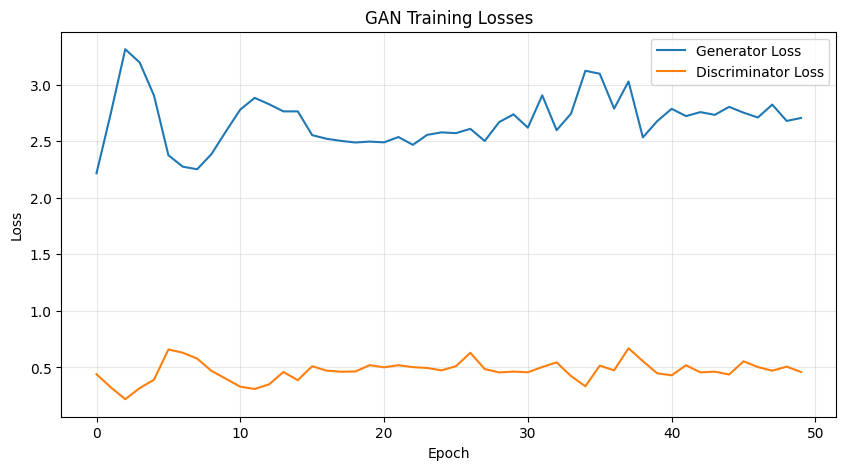

In [22]:
plt.figure(figsize=(10, 5))
plt.plot(gen_losses, label="Generator Loss")
plt.plot(disc_losses, label="Discriminator Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("GAN Training Losses")
plt.legend()
plt.grid(alpha=0.3)
plt.savefig(f"{MODEL_SAVE_DIR}/../loss_curve.png")
plt.show()

## 12. Compare generated faces across epochs

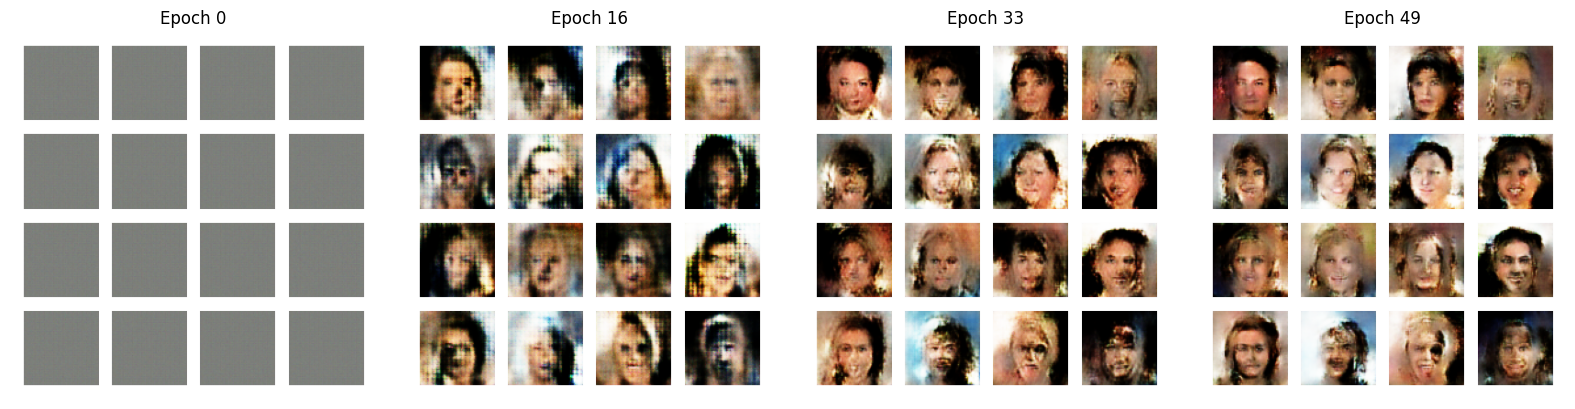

In [23]:
available = sorted(int(f.split("_")[1].split(".")[0]) for f in os.listdir(SAMPLE_DIR) if f.startswith("epoch_"))
n = len(available)
idxs = sorted(set([0, n // 3, (2 * n) // 3, n - 1]))
epochs_to_show = [available[i] for i in idxs]

fig, axes = plt.subplots(1, len(epochs_to_show), figsize=(4 * len(epochs_to_show), 4))
for ax, ep in zip(axes, epochs_to_show):
    ax.imshow(plt.imread(f"{SAMPLE_DIR}/epoch_{ep:04d}.png"))
    ax.set_title(f"Epoch {ep}")
    ax.axis("off")
plt.tight_layout()
plt.savefig(f"{MODEL_SAVE_DIR}/../epoch_comparison.png")
plt.show()